# NB02 — Univariate Hypothesis Tests (v2)

Tests **H1a** (euk fraction differs by matrix/ecosystem) and **H1b** (the eukaryotic *source* — photosynthetic
plastid vs protist/fungal — tracks environment). First look at **H1c** (platform/depth). Non-parametric on the
primary response `gott_euk_frac` (run-level, `nmdc.results`). The adjusted / out-of-study test is NB03; the
batch-controlled within-study test is NB04.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, itertools
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
DATA=Path('../data'); FIG=Path('../figures')
plt.rcParams.update({'figure.dpi':110,'savefig.bbox':'tight','axes.grid':True,'grid.alpha':.3})
df=pd.read_csv(DATA/'analysis_clean.csv'); print(len(df),'runs,',df.study_id.nunique(),'studies')

2760 runs, 9 studies


## Confound check: matrix is largely nested within study

In [2]:
ct=pd.crosstab(df['matrix'],df['study_id'])
print('n studies per matrix:'); print((ct>0).sum(axis=1).to_string())
conc=ct.div(ct.sum(axis=1),axis=0).max(axis=1).round(2)
print('\nfraction of each matrix in its single most common study:'); print(conc.to_string())
print('\n=> environment still partly nested in study; NB03 GroupKFold + NB04 within-study address this.')

n studies per matrix:
matrix
Aquatic        2
Plants         1
Terrestrial    5
Unknown        3

fraction of each matrix in its single most common study:
matrix
Aquatic        0.73
Plants         1.00
Terrestrial    0.80
Unknown        0.45

=> environment still partly nested in study; NB03 GroupKFold + NB04 within-study address this.


## H1a — Eukaryotic fraction by matrix (ecosystem_category)

In [3]:
groups=[g for g in ['Terrestrial','Aquatic','Plants','Artificial ecosystem'] if (df['matrix']==g).sum()>=10]
dm=df[df['matrix'].isin(groups)].copy()
H,p=stats.kruskal(*[dm.loc[dm.matrix==g,'gott_euk_frac'] for g in groups])
print(f'Kruskal-Wallis across matrix: H={H:.1f}, p={p:.2e}')
summ=dm.groupby('matrix')['gott_euk_frac'].agg(n='size',median='median',mean='mean',
     detect=lambda s:(s>0).mean(),gt20=lambda s:(s>0.2).mean()).round(4).reindex(groups)
display(summ)
rows=[]
for a,b in itertools.combinations(groups,2):
    u,pp=stats.mannwhitneyu(dm.loc[dm.matrix==a,'gott_euk_frac'],dm.loc[dm.matrix==b,'gott_euk_frac'])
    rows.append((a,b,pp))
pw=pd.DataFrame(rows,columns=['a','b','p']); pw['p_fdr']=multipletests(pw['p'],method='fdr_bh')[1]
pw['sig']=pw['p_fdr']<0.05; display(pw.round(4)); pw.to_csv(DATA/'h1a_pairwise_matrix.csv',index=False)

Kruskal-Wallis across matrix: H=77.8, p=1.30e-17


,n,median,mean,detect,gt20
matrix,,,,,
Terrestrial,928,0.0099,0.0859,0.5571,0.1455
Aquatic,622,0.0154,0.0464,0.9952,0.0531
Plants,208,0.0549,0.0935,1.0000,0.1058


,a,b,p,p_fdr,sig
0,Terrestrial,Aquatic,0.0,0.0,True
1,Terrestrial,Plants,0.0,0.0,True
2,Aquatic,Plants,0.0,0.0,True


## H1a (finer) — by ecosystem_type (excluding the `Unknown`/missing-metadata bucket)

In [4]:
top=[t for t in df['ecosystem_type'].value_counts().index if t!='Unknown'][:8]  # exclude missing-metadata bucket
et=df[df['ecosystem_type'].isin(top)]
etsum=et.groupby('ecosystem_type')['gott_euk_frac'].agg(n='size',median='median',
      detect=lambda s:(s>0).mean(),gt20=lambda s:(s>0.2).mean()).round(4).sort_values('median',ascending=False)
display(etsum); etsum.to_csv(DATA/'h1a_ecosystem_type.csv')
H2,p2=stats.kruskal(*[et.loc[et.ecosystem_type==t,'gott_euk_frac'] for t in top])
print(f'Kruskal across ecosystem_type: H={H2:.1f}, p={p2:.2e}')

,n,median,detect,gt20
ecosystem_type,,,,
Roots,208,0.0549,1.0000,0.1058
Freshwater,622,0.0154,0.9952,0.0531
Soil,928,0.0099,0.5571,0.1455


Kruskal across ecosystem_type: H=77.8, p=1.30e-17


## Figure 2 — Euk fraction by environment

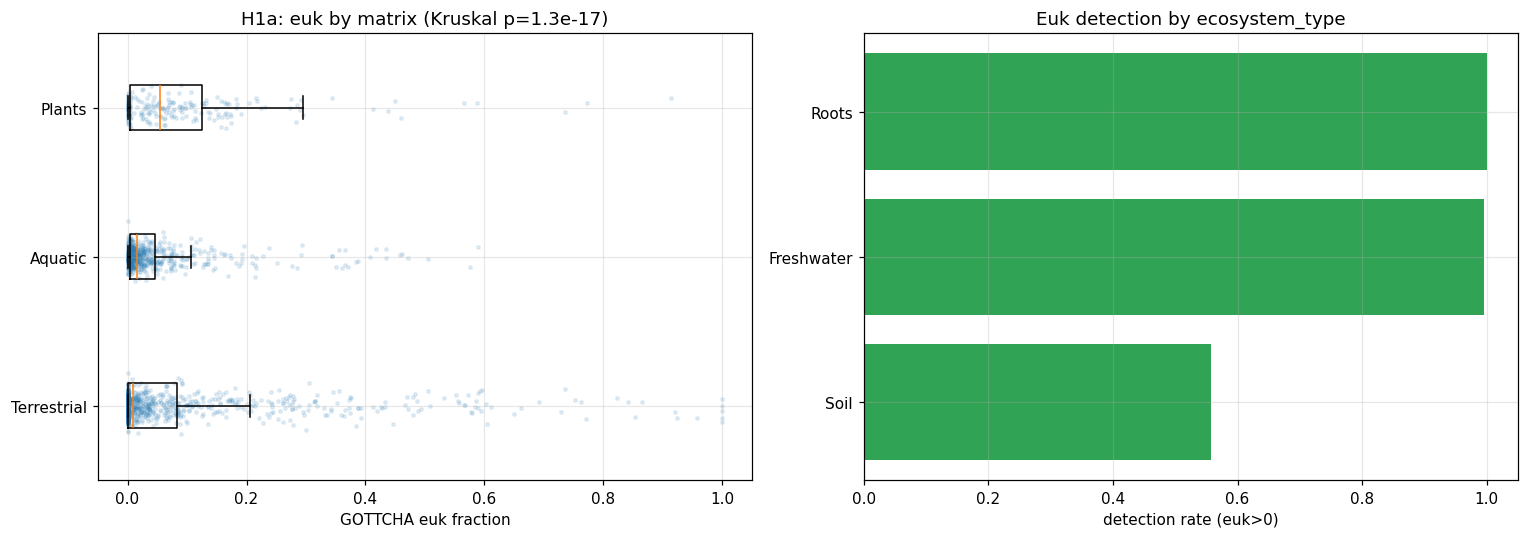

saved fig02


In [5]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
ax=axes[0]; order=summ.sort_values('median').index.tolist()
ax.boxplot([dm.loc[dm.matrix==g,'gott_euk_frac'] for g in order],vert=False,tick_labels=order,showfliers=False)
for i,g in enumerate(order):
    v=dm.loc[dm.matrix==g,'gott_euk_frac']
    ax.scatter(v,np.random.normal(i+1,.06,size=len(v)),s=5,alpha=.12,color='#2c7fb8')
ax.set_xlabel('GOTTCHA euk fraction'); ax.set_title(f'H1a: euk by matrix (Kruskal p={p:.1e})')
ax=axes[1]; e2=etsum.sort_values('detect')
ax.barh(e2.index,e2['detect'],color='#31a354'); ax.set_xlabel('detection rate (euk>0)')
ax.set_title('Euk detection by ecosystem_type')
plt.tight_layout(); plt.savefig(FIG/'fig02_euk_by_environment.png'); plt.show(); print('saved fig02')

## H1b — Source attribution: plastid (photosynthetic) dominates and tracks environment

In [6]:
src=dm.groupby('matrix').agg(
    plastid_detect=('gott_plastid_frac',lambda s:(s>0).mean()),
    plastid_median=('gott_plastid_frac','median'),
    protist_detect=('gott_euk_nonplastid_frac',lambda s:(s>0).mean()),
    protist_median=('gott_euk_nonplastid_frac','median')).round(4).reindex(groups)
print('Plastid (plant/algal) vs protist/fungal by matrix:'); display(src); src.to_csv(DATA/'h1b_source_by_matrix.csv')
# plastid share of euk by matrix
dd=dm[dm['gott_euk_frac']>0].copy(); dd['plastid_share']=dd['gott_plastid_frac']/dd['gott_euk_frac']
print('median plastid share of euk signal by matrix:')
print(dd.groupby('matrix')['plastid_share'].median().round(2).reindex(groups).to_string())

Plastid (plant/algal) vs protist/fungal by matrix:


,plastid_detect,plastid_median,protist_detect,protist_median
matrix,,,,
Terrestrial,0.3610,0.0000,0.4149,0.0000
Aquatic,0.9952,0.0154,0.0305,0.0000
Plants,0.7500,0.0005,1.0000,0.0408


median plastid share of euk signal by matrix:
matrix
Terrestrial    0.43
Aquatic        1.00
Plants         0.03


## H1c (preview) — platform & depth

In [7]:
known=df[df['platform']!='Unknown']
psum=known.groupby('platform')['gott_euk_frac'].agg(n='size',median='median',
     detect=lambda s:(s>0).mean()).round(4).sort_values('n',ascending=False); display(psum)
dd2=df[df['depth_m'].notna()&(df['depth_m']>0)]
if len(dd2)>20:
    rho,pdep=stats.spearmanr(dd2['depth_m'],dd2['gott_euk_frac'])
    print(f'Spearman euk vs depth (n={len(dd2)}): rho={rho:.2f}, p={pdep:.2e}')
else:
    print(f'depth measured for only {len(dd2)} runs -> not testable.')
print('\nAdjusted H1c (does platform/depth add beyond matrix?) -> NB03.')

,n,median,detect
platform,,,
novaseq_6000,899,0.0206,0.9811
novaseq,92,0.0157,0.9457
hiseq_2500,28,0.0241,1.0000


Spearman euk vs depth (n=292): rho=-0.29, p=5.22e-07

Adjusted H1c (does platform/depth add beyond matrix?) -> NB03.


## NB02 takeaways
- **H1a (univariate):** euk fraction differs strongly across matrix/ecosystem (Kruskal p reported above).
- **H1b:** the eukaryotic signal is **photosynthetic-plastid dominated** across all matrices; the plastid share of
  euk is high everywhere, with protist/fungal a secondary, environment-varying component.
- **Caveat:** matrix still partly nested in study — the adjusted (NB03) and batch-controlled within-study (NB04)
  tests are required before an environment claim.